In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [10]:
df=pd.read_csv('compressed_captions.csv')

df1=df['caption'].reset_index()
df1=df1.rename(columns = {'index':'dexnum'})
df1['dexnum']=df1['dexnum']+1
df1['caption']=df1['caption'].str.split()
#.. używamy biblioteki re aby usunać wszelkie znaki niebędące literami, cyframi, podkreśleniami (\w) ani białymi znakami (spacje, tabulacje, nowe linie - \s)
df1['caption'] = df1['caption'].apply(lambda row: [re.sub(r'[^\w\s]', '', x).lower() for x in row]) 
df1['caption'] = df1['caption'].apply(lambda x: [word for word in x if len(word) > 3])
df1

,dexnum,caption
0,1,"[small, amphibian, pokémon, bluegreen, skin, w..."
1,2,"[ivysaur, short, rounded, snout, with, wide, m..."
2,3,"[squat, quadrupedal, amphibian, pokémon, bumpy..."
3,4,"[bipedal, reptilian, pokémon, with, primarily,..."
4,5,"[dark, scales, cream, underside, from, chest, ..."
...,...,...
1020,1021,"[massive, quadrupedal, yellow, sauropodlike, p..."
1021,1022,"[spherical, bulllike, pokémon, coated, reflect..."
1022,1023,"[luminous, head, yellow, metal, horns, similar..."
1023,1024,"[small, reptilian, pokémon, resembles, indigo,..."


In [11]:
#..'explode' rozbija listę w kolumnie 'caption' na osobne wiersze
df_words_all = df1.explode('caption')
df_words_all = df_words_all.reset_index(drop=True)
df_words_all

,dexnum,caption
0,1,small
1,1,amphibian
2,1,pokémon
3,1,bluegreen
4,1,skin
...,...,...
21303,1025,into
21304,1025,halves
21305,1025,face
21306,1025,white


In [12]:
#QUEENPANTERIN ZACZYNA PRACE

counts_cap=df_words_all['caption'].value_counts()
counts_cap=counts_cap.drop(['with','also','this','there','than','them','that','each','which','have','into','over','either'])
counts_cap.head(25)

caption
pokémon    810
body       489
eyes       423
head       416
black      375
large      302
yellow     297
blue       293
white      278
small      274
bipedal    198
tail       179
long       177
brown      166
dark       166
green      158
pink       149
light      147
three      144
legs       142
back       138
face       138
ears       135
gray       135
arms       125
Name: count, dtype: int64

In [13]:
import seaborn as sns
from wordcloud import WordCloud, ImageColorGenerator
from PIL import Image

In [14]:
counts_cap=counts_cap.reset_index()
counts_cap

,caption,count
0,pokémon,810
1,body,489
2,eyes,423
3,head,416
4,black,375
...,...,...
3064,metang,1
3065,cannot,1
3066,discshaped,1
3067,joint,1


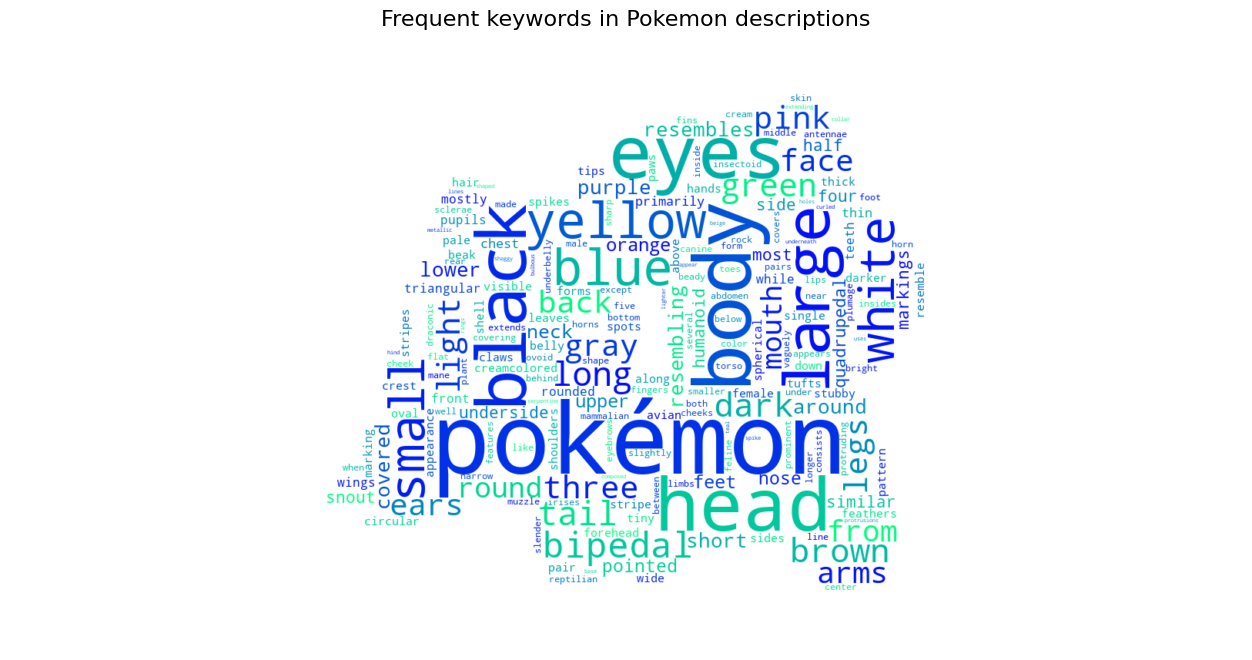

In [17]:
counts_cap=counts_cap.sort_values(by='count',ascending=False)
mask = np.array(Image.open("canva2.png"))

freq=counts_cap.set_index('caption')['count']
freqd=freq.to_dict()
chmura=WordCloud(
    background_color='white',
    mask=mask,
    colormap='winter',
    width=1600,
    height=800
)
chmura.generate_from_frequencies(freqd)
plt.figure(figsize=(16,8))
plt.imshow(chmura, interpolation='bilinear')
plt.axis('off')
plt.title('Frequent keywords in Pokemon descriptions', fontsize=16)
plt.savefig('wordcloud.png')
plt.show()